# Capstone EDA — StatsBomb + Polymarket

This notebook explores the two datasets at the core of our capstone project:
- **StatsBomb** open football event data (matches, events, lineups, 360° tracking, reference)
- **Polymarket** soccer prediction-market data (markets, tokens, trades, odds history, summaries)

**Performance strategy for large files:**  
- `events.parquet` (755 MB) and `three_sixty.parquet` (284 MB) are queried **in-place** via DuckDB — no full load into RAM.  
- `soccer_trades.parquet` (123 MB) is also queried via DuckDB.  
- Smaller files are loaded with pandas/pyarrow as normal.

## 0. Setup

In [1]:
# Install dependencies if not already present
# %pip install duckdb pandas pyarrow matplotlib seaborn

In [2]:
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ──────────────────────────────────────────────────────────────────
# Parquet files live under data/ at the project root. CWD may be repo root or notebooks/.
_cwd = Path.cwd()
if (_cwd / "data" / "Statsbomb").is_dir():
    ROOT = _cwd
elif (_cwd.parent / "data" / "Statsbomb").is_dir():
    ROOT = _cwd.parent
else:
    ROOT = _cwd

SB = os.path.join(ROOT, "data", "Statsbomb")
PM = os.path.join(ROOT, "data", "Polymarket")

SB_MATCHES  = os.path.join(SB, 'matches.parquet')
SB_EVENTS   = os.path.join(SB, 'events.parquet')      # 755 MB — DuckDB only
SB_LINEUPS  = os.path.join(SB, 'lineups.parquet')
SB_360      = os.path.join(SB, 'three_sixty.parquet') # 284 MB — DuckDB only
SB_REF      = os.path.join(SB, 'reference.parquet')

PM_MARKETS  = os.path.join(PM, 'soccer_markets.parquet')
PM_TOKENS   = os.path.join(PM, 'soccer_tokens.parquet')
PM_TRADES   = os.path.join(PM, 'soccer_trades.parquet')  # 123 MB — DuckDB only
PM_ODDS     = os.path.join(PM, 'soccer_odds_history.parquet')
PM_STATS    = os.path.join(PM, 'soccer_event_stats.parquet')
PM_SUMMARY  = os.path.join(PM, 'soccer_summary.parquet')

FIGURES_DIR = os.path.join(ROOT, 'results', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── DuckDB in-memory connection ────────────────────────────────────────────
con = duckdb.connect()

def duck(sql: str) -> pd.DataFrame:
    """Run a DuckDB SQL query and return a DataFrame."""
    return con.execute(sql).df()

print('Setup complete.')

Setup complete.


---
## 1. StatsBomb — Matches

In [3]:
matches = pd.read_parquet(SB_MATCHES)
print(f'Shape: {matches.shape}')
matches.head()

Shape: (3464, 36)


,match_id,match_date,match_week,match_status,match_status_360,kickoff,home_score,away_score,competition_id,competition,competition_stage,season_id,season,home_team_id,home_team,home_managers,away_team_id,away_team,away_managers,stadium_id,stadium,referee_id,referee,last_updated,last_updated_360,data_version,shot_fidelity_version,xy_fidelity_version,competition_name,gender,is_youth,is_international,country_name,season_name,match_updated,match_available_360
0,9880,2018-04-14,32,available,scheduled,16:15:00,2,1,11,La Liga,Regular Season,1,2017/2018,217,Barcelona,"[{""id"":227,""name"":""Ernesto Valverde Tejedor"",""nickname"":...",207,Valencia,"[{""id"":211,""name"":""Marcelino García Toral"",""nickname"":""M...",342.0,Spotify Camp Nou,2728.0,Carlos del Cerro Grande,2023-02-08T17:23:53.901920,2021-06-13T16:17:31.694,1.1.0,2,2,La Liga,male,False,False,Spain,2017/2018,2025-07-14T10:01:16.674864,NaN
1,9912,2018-04-29,35,available,scheduled,20:45:00,2,4,11,La Liga,Regular Season,1,2017/2018,219,RC Deportivo La Coruña,"[{""id"":371,""name"":""Clarence Seedorf"",""nickname"":null,""do...",217,Barcelona,"[{""id"":227,""name"":""Ernesto Valverde Tejedor"",""nickname"":...",4658.0,Estadio Abanca-Riazor,2602.0,Ricardo De Burgos Bengoetxea,2022-12-05T14:42:44.641092,2021-06-13T16:17:31.694,1.1.0,2,2,La Liga,male,False,False,Spain,2017/2018,2025-07-14T10:01:16.674864,NaN
2,9924,2018-05-06,36,available,scheduled,20:45:00,2,2,11,La Liga,Regular Season,1,2017/2018,217,Barcelona,"[{""id"":227,""name"":""Ernesto Valverde Tejedor"",""nickname"":...",220,Real Madrid,"[{""id"":56,""name"":""Zinédine Zidane"",""nickname"":null,""dob""...",342.0,Spotify Camp Nou,2608.0,Alejandro José Hernández Hernández,2022-12-01T03:25:12.063586,2021-06-13T16:17:31.694,1.1.0,2,2,La Liga,male,False,False,Spain,2017/2018,2025-07-14T10:01:16.674864,NaN
3,9855,2018-03-18,29,available,scheduled,16:15:00,2,0,11,La Liga,Regular Season,1,2017/2018,217,Barcelona,"[{""id"":227,""name"":""Ernesto Valverde Tejedor"",""nickname"":...",215,Athletic Club,"[{""id"":210,""name"":""José Ángel Ziganda Lacunza"",""nickname...",342.0,Spotify Camp Nou,2575.0,Santiago Jaime Latre,2022-12-01T02:33:31.178193,2021-06-13T16:17:31.694,1.1.0,2,2,La Liga,male,False,False,Spain,2017/2018,2025-07-14T10:01:16.674864,NaN
4,9827,2018-03-01,26,available,scheduled,21:00:00,1,1,11,La Liga,Regular Season,1,2017/2018,208,Las Palmas,"[{""id"":220,""name"":""Francisco Jémez Martín"",""nickname"":""P...",217,Barcelona,"[{""id"":227,""name"":""Ernesto Valverde Tejedor"",""nickname"":...",357.0,Estadio de Gran Canaria,180.0,Antonio Miguel Mateu Lahoz,2022-08-04T17:18:06.540844,2021-06-13T16:17:31.694,1.1.0,2,2,La Liga,male,False,False,Spain,2017/2018,2025-07-14T10:01:16.674864,NaN


In [4]:
print('Data types:')
print(matches.dtypes)
print('\nMissing values:')
print(matches.isnull().sum())

Data types:
match_id                   int32
match_date                   str
match_week                 int32
match_status                 str
match_status_360             str
kickoff                      str
home_score                 int32
away_score                 int32
competition_id             int32
competition                  str
competition_stage            str
season_id                  int32
season                       str
home_team_id               int32
home_team                    str
home_managers                str
away_team_id               int32
away_team                    str
away_managers                str
stadium_id               float64
stadium                      str
referee_id               float64
referee                      str
last_updated                 str
last_updated_360             str
data_version                 str
shot_fidelity_version        str
xy_fidelity_version          str
competition_name             str
gender                       st

In [5]:
print('Competitions covered:')
print(matches.groupby('competition_name')['match_id'].count().sort_values(ascending=False).to_string())

Competitions covered:
competition_name
La Liga                    868
Ligue 1                    435
Premier League             418
Serie A                    381
1. Bundesliga              340
FA Women's Super League    326
FIFA World Cup             147
Women's World Cup          116
Indian Super league        115
UEFA Euro                  102
UEFA Women's Euro           62
African Cup of Nations      52
NWSL                        36
Copa America                32
Champions League            18
Major League Soccer          6
Copa del Rey                 3
UEFA Europa League           3
Liga Profesional             2
FIFA U20 World Cup           1
North American League        1


In [6]:
print('Seasons covered:')
print(matches.groupby(['competition_name','season_name'])['match_id'].count()
      .reset_index()
      .rename(columns={'match_id': 'num_matches'})
      .sort_values(['competition_name','season_name'])
      .to_string(index=False))

Seasons covered:
       competition_name season_name  num_matches
          1. Bundesliga   2015/2016          306
          1. Bundesliga   2023/2024           34
 African Cup of Nations        2023           52
       Champions League   1970/1971            1
       Champions League   1971/1972            1
       Champions League   1972/1973            1
       Champions League   1999/2000            1
       Champions League   2003/2004            1
       Champions League   2004/2005            1
       Champions League   2006/2007            1
       Champions League   2008/2009            1
       Champions League   2009/2010            1
       Champions League   2010/2011            1
       Champions League   2011/2012            1
       Champions League   2012/2013            1
       Champions League   2013/2014            1
       Champions League   2014/2015            1
       Champions League   2015/2016            1
       Champions League   2016/2017            1
   

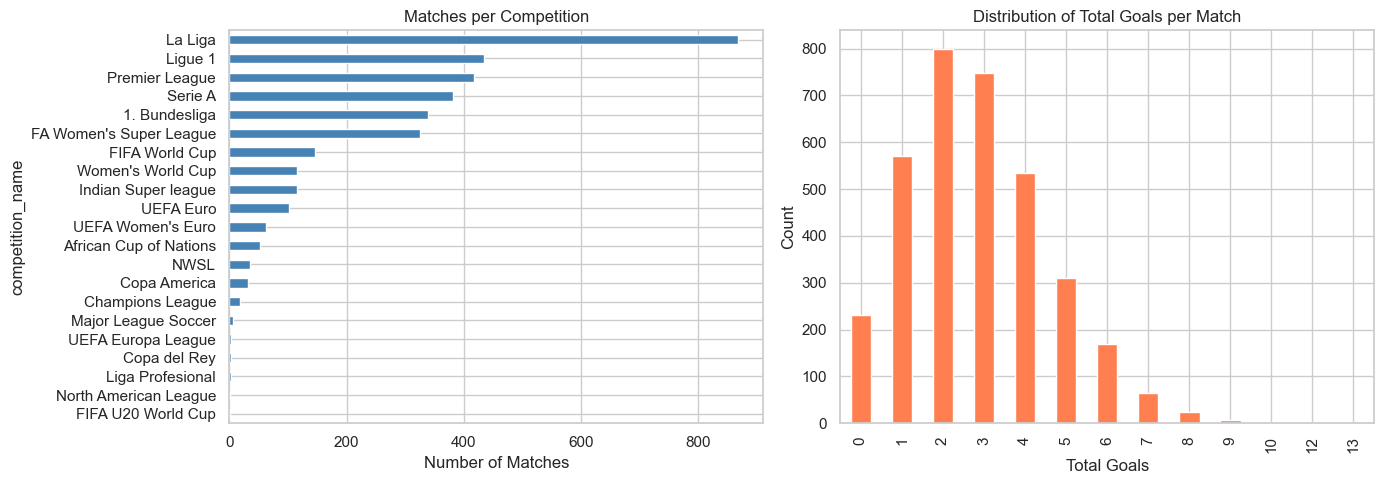

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matches per competition
comp_counts = matches['competition_name'].value_counts()
comp_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Matches per Competition')
axes[0].set_xlabel('Number of Matches')
axes[0].invert_yaxis()

# Goal distribution
matches['total_goals'] = matches['home_score'] + matches['away_score']
matches['total_goals'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribution of Total Goals per Match')
axes[1].set_xlabel('Total Goals')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sb_matches_competitions_and_goals.png'), dpi=150, bbox_inches='tight')
plt.show()

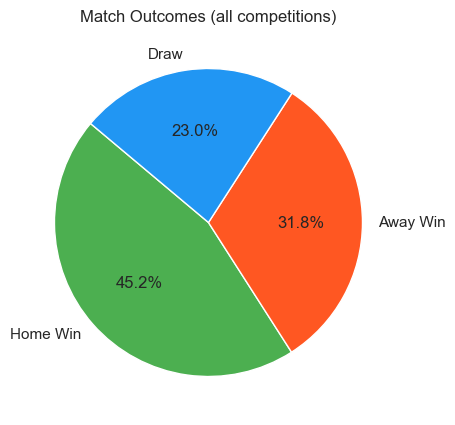

In [8]:
# Home vs Away win rates
def result(row):
    if row['home_score'] > row['away_score']:  return 'Home Win'
    if row['home_score'] < row['away_score']:  return 'Away Win'
    return 'Draw'

matches['result'] = matches.apply(result, axis=1)
result_counts = matches['result'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(result_counts, labels=result_counts.index, autopct='%1.1f%%',
       colors=['#4CAF50','#FF5722','#2196F3'], startangle=140)
ax.set_title('Match Outcomes (all competitions)')
plt.savefig(os.path.join(FIGURES_DIR, 'sb_match_outcomes_pie.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2. StatsBomb — Events (755 MB, DuckDB)

In [9]:
# ── Schema & row count ─────────────────────────────────────────────────────
print('Schema:')
display(duck(f"DESCRIBE SELECT * FROM read_parquet('{SB_EVENTS}')"))

n_events = duck(f"SELECT COUNT(*) AS n FROM read_parquet('{SB_EVENTS}')")['n'][0]
print(f'\nTotal events: {n_events:,}')

Schema:


,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,index_num,INTEGER,YES,None,None,None
2,period,INTEGER,YES,None,None,None
3,minute,INTEGER,YES,None,None,None
4,second,INTEGER,YES,None,None,None
...,...,...,...,...,...,...
107,substitution_replacement_name,VARCHAR,YES,None,None,None
108,substitution_outcome,VARCHAR,YES,None,None,None
109,fifty_fifty_outcome,VARCHAR,YES,None,None,None
110,bad_behaviour_card,VARCHAR,YES,None,None,None



Total events: 12,188,949


In [10]:
# ── Event type distribution ────────────────────────────────────────────────
event_types = duck(f"""
    SELECT type, COUNT(*) AS n
    FROM read_parquet('{SB_EVENTS}')
    GROUP BY type
    ORDER BY n DESC
""")
print(event_types.to_string(index=False))

             type       n
             Pass 3387760
    Ball Receipt* 3167310
            Carry 2632570
         Pressure 1113859
    Ball Recovery  366673
             Duel  257861
        Clearance  158993
            Block  132352
          Dribble  122047
      Goal Keeper  106574
   Foul Committed  100510
       Miscontrol   99391
         Foul Won   95596
     Dispossessed   88814
             Shot   88023
     Interception   79641
    Dribbled Past   76284
     Substitution   21514
       Half Start   14128
         Half End   14128
  Injury Stoppage   13889
            50/50   10493
   Tactical Shift    8678
      Starting XI    6928
           Shield    4645
Referee Ball-Drop    4249
       Player Off    3318
        Player On    3290
        Camera On    2595
    Bad Behaviour    2531
            Error    1703
          Offside    1235
       Camera off     693
     Own Goal For     337
 Own Goal Against     337


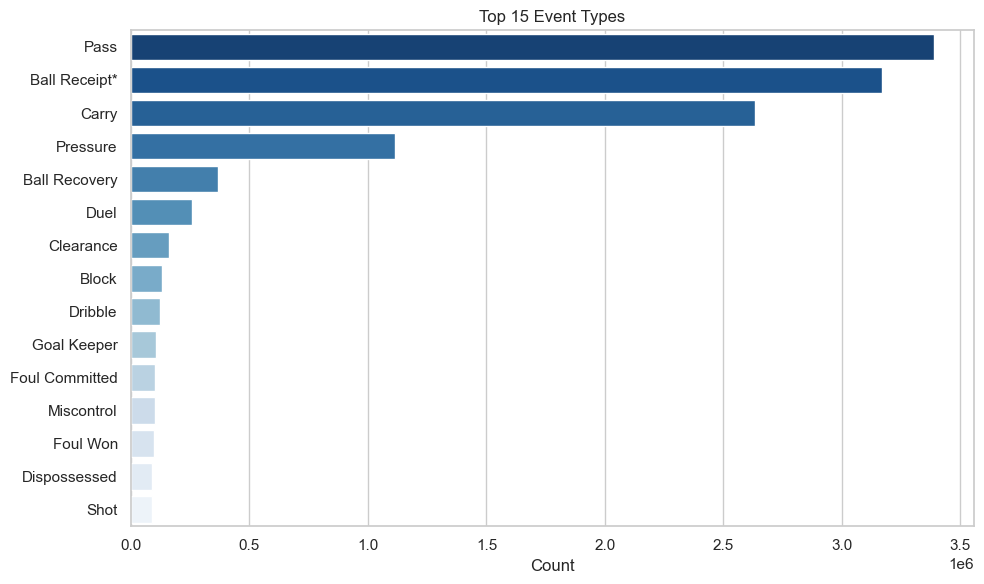

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
top_events = event_types.head(15)
sns.barplot(data=top_events, x='n', y='type', palette='Blues_r', ax=ax)
ax.set_title('Top 15 Event Types')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sb_top_event_types.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Shot & xG analysis ─────────────────────────────────────────────────────
shots = duck(f"""
    SELECT match_id, team, player, location_x, location_y,
           shot_statsbomb_xg, play_pattern
    FROM read_parquet('{SB_EVENTS}')
    WHERE type = 'Shot'
      AND shot_statsbomb_xg IS NOT NULL
""")
print(f'Total shots with xG: {len(shots):,}')
shots.describe()

Total shots with xG: 88,023


,match_id,location_x,location_y,shot_statsbomb_xg
count,8.802300e+04,88023.000000,88023.000000,88023.000000
mean,2.981681e+06,103.590355,39.763710,0.106599
std,1.553676e+06,8.795212,9.885723,0.149922
min,7.298000e+03,30.200001,0.300000,0.000180
25%,3.749310e+06,97.300003,32.500000,0.027747
50%,3.825651e+06,105.000000,40.000000,0.054884
75%,3.879869e+06,110.599998,47.000000,0.110167
max,4.020846e+06,120.500000,80.000000,0.995122


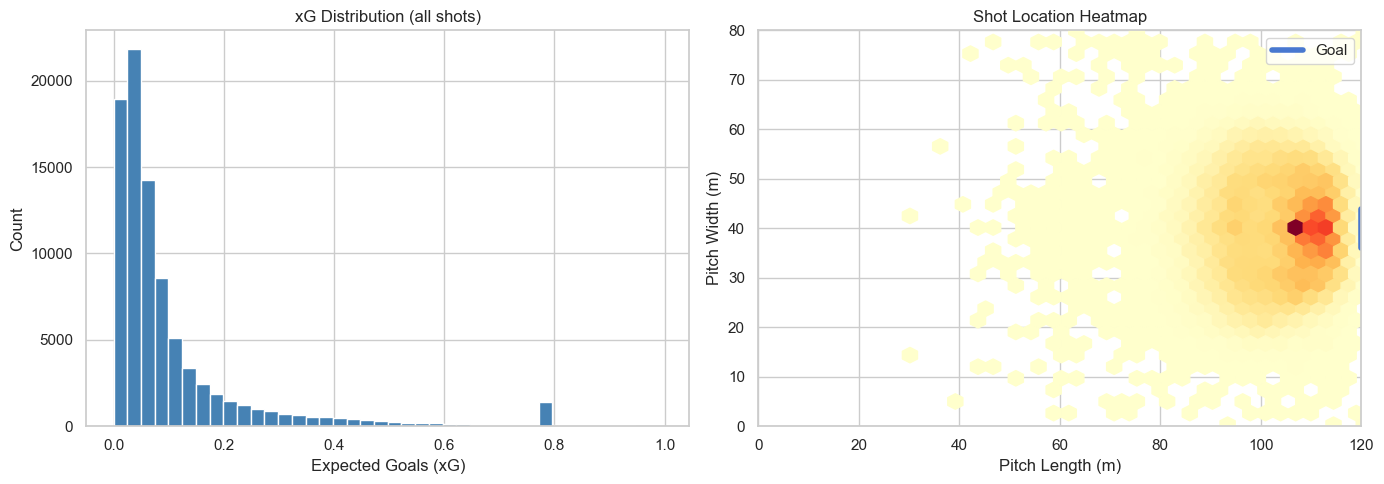

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# xG distribution
axes[0].hist(shots['shot_statsbomb_xg'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('xG Distribution (all shots)')
axes[0].set_xlabel('Expected Goals (xG)')
axes[0].set_ylabel('Count')

# Shot location heatmap (pitch coords: x 0-120, y 0-80)
axes[1].hexbin(shots['location_x'], shots['location_y'],
               gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlim(0, 120)
axes[1].set_ylim(0, 80)
axes[1].set_title('Shot Location Heatmap')
axes[1].set_xlabel('Pitch Length (m)')
axes[1].set_ylabel('Pitch Width (m)')
# Mark the goal
axes[1].plot([120, 120], [36, 44], 'b-', linewidth=4, label='Goal')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sb_xg_and_shot_locations.png'), dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Top xG teams (aggregate) ───────────────────────────────────────────────
xg_by_team = duck(f"""
    SELECT team,
           COUNT(*)                          AS shots,
           ROUND(SUM(shot_statsbomb_xg), 2)  AS total_xg,
           ROUND(AVG(shot_statsbomb_xg), 4)  AS avg_xg_per_shot
    FROM read_parquet('{SB_EVENTS}')
    WHERE type = 'Shot' AND shot_statsbomb_xg IS NOT NULL
    GROUP BY team
    ORDER BY total_xg DESC
    LIMIT 20
""")
xg_by_team

,team,shots,total_xg,avg_xg_per_shot
0,Barcelona,8401,1069.08,0.1273
1,Paris Saint-Germain,1432,196.52,0.1372
2,Chelsea FCW,1153,143.26,0.1242
3,Manchester City WFC,1088,137.81,0.1267
4,Arsenal WFC,968,132.71,0.1371
5,Real Madrid,1188,132.02,0.1111
6,Arsenal,1127,126.01,0.1118
7,Bayer Leverkusen,1103,122.49,0.1111
8,Manchester United,1051,110.22,0.1049
9,Bayern Munich,742,88.40,0.1191


In [15]:
# ── Pass completion rate by team (aggregated) ──────────────────────────────
pass_stats = duck(f"""
    SELECT team,
           COUNT(*) AS total_passes,
           SUM(CASE WHEN pass_outcome IS NULL THEN 1 ELSE 0 END) AS completed,
           ROUND(100.0 * SUM(CASE WHEN pass_outcome IS NULL THEN 1 ELSE 0 END)
                 / COUNT(*), 1) AS completion_pct
    FROM read_parquet('{SB_EVENTS}')
    WHERE type = 'Pass'
    GROUP BY team
    HAVING total_passes > 500
    ORDER BY completion_pct DESC
    LIMIT 20
""")
pass_stats

,team,total_passes,completed,completion_pct
0,Paris Saint-Germain,69070,61523.0,89.1
1,Spain,17064,15194.0,89.0
2,Barcelona,368450,318796.0,86.5
3,Bayern Munich,29641,25638.0,86.5
4,Italy,7224,6240.0,86.4
5,Strasbourg,883,759.0,86.0
6,Germany,11331,9740.0,86.0
7,Argentina U20,525,451.0,85.9
8,Portugal,11348,9722.0,85.7
9,Inter Miami,3643,3120.0,85.6


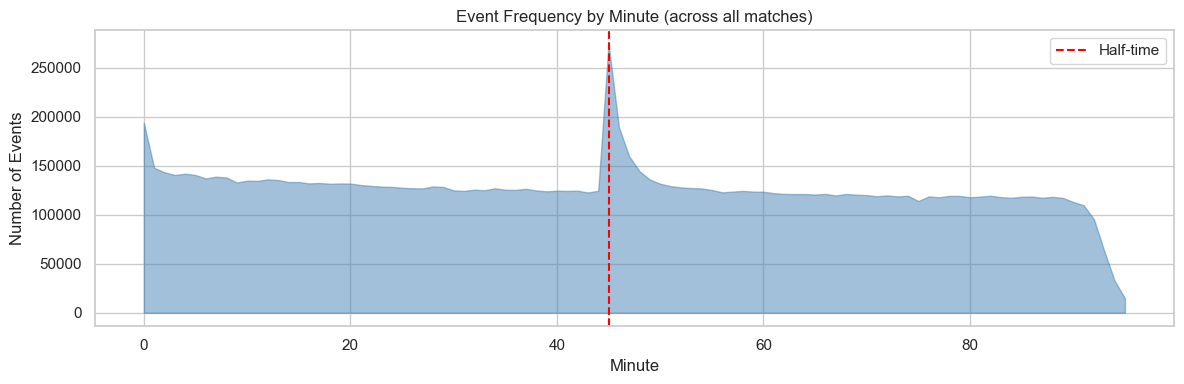

In [16]:
# ── Events per minute (game tempo) ────────────────────────────────────────
tempo = duck(f"""
    SELECT minute, COUNT(*) AS events
    FROM read_parquet('{SB_EVENTS}')
    WHERE period IN (1, 2) AND minute <= 95
    GROUP BY minute
    ORDER BY minute
""")

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(tempo['minute'], tempo['events'], alpha=0.5, color='steelblue')
ax.axvline(45, color='red', linestyle='--', label='Half-time')
ax.set_title('Event Frequency by Minute (across all matches)')
ax.set_xlabel('Minute')
ax.set_ylabel('Number of Events')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sb_events_per_minute.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. StatsBomb — Lineups

In [17]:
lineups = pd.read_parquet(SB_LINEUPS)
print(f'Shape: {lineups.shape}')
lineups.head()

Shape: (165820, 17)


,match_id,team_id,player_id,player_name,player_nickname,jersey_number,country_id,country_name,team_name,position_name,from_time,to_time,from_period,to_period,card_time,card_type,card_reason
0,15946,206,6839,Daniel Alejandro Torres Rojas,Dani Torres,16,49.0,Colombia,Deportivo Alavés,Center Defensive Midfield,00:00,67:48,1.0,2.0,09:15,Yellow Card,Foul Committed
1,15946,206,6855,Guillermo Alfonso Maripán Loaysa,Guillermo Maripán,6,45.0,Chile,Deportivo Alavés,Left Center Back,00:00,NaN,1.0,NaN,40:46,Yellow Card,Bad Behaviour
2,15956,217,5213,Gerard Piqué Bernabéu,Gerard Piqué,3,214.0,Spain,Barcelona,Right Center Back,00:00,NaN,1.0,NaN,59:01,Yellow Card,Foul Committed
3,15956,901,6760,Enes Ünal,NaN,9,233.0,Turkey,Real Valladolid,Right Center Forward,00:00,69:51,1.0,2.0,48:43,Yellow Card,Foul Committed
4,15973,217,8206,Arturo Erasmo Vidal Pardo,Arturo Vidal,22,45.0,Chile,Barcelona,Right Center Midfield,70:46,70:49,2.0,2.0,87:18,Yellow Card,Foul Committed


In [18]:
print('Missing values:')
print(lineups.isnull().sum())
print(f'\nUnique players : {lineups["player_name"].nunique():,}')
print(f'Unique positions: {lineups["position_name"].nunique()}')
print(f'Unique teams   : {lineups["team_name"].nunique()}')

Missing values:
match_id                0
team_id                 0
player_id               0
player_name             0
player_nickname    102553
jersey_number           0
country_id             18
country_name           18
team_name               0
position_name       34179
from_time           34179
to_time            110917
from_period         34179
to_period          110917
card_time          146214
card_type          146214
card_reason        146214
dtype: int64

Unique players : 10,808
Unique positions: 25
Unique teams   : 308


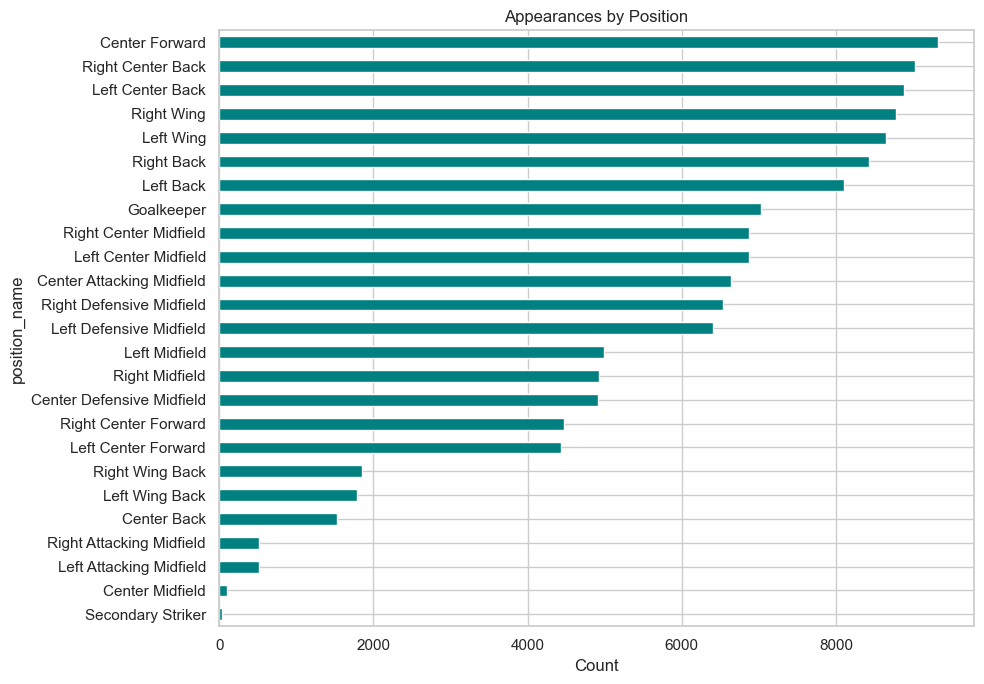

In [19]:
# Position frequency
pos_counts = (lineups.dropna(subset=['position_name'])
              .groupby('position_name')['player_name']
              .count()
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 7))
pos_counts.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Appearances by Position')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sb_appearances_by_position.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Card analysis
cards = lineups[lineups['card_type'].notna()]
print(f'Total disciplinary actions: {len(cards)}')
print(cards['card_type'].value_counts())

Total disciplinary actions: 19606
card_type
Yellow Card      18217
Second Yellow      697
Red Card           692
Name: count, dtype: int64


---
## 4. StatsBomb — 360° Tracking (284 MB, DuckDB)

In [21]:
n_360 = duck(f"SELECT COUNT(*) AS n FROM read_parquet('{SB_360}')")['n'][0]
print(f'Total tracking frames: {n_360:,}')

print('\nSchema:')
display(duck(f"DESCRIBE SELECT * FROM read_parquet('{SB_360}')"))

Total tracking frames: 15,584,040

Schema:


,column_name,column_type,null,key,default,extra
0,match_id,INTEGER,YES,None,None,None
1,id,INTEGER,YES,None,None,None
2,event_uuid,VARCHAR,YES,None,None,None
3,teammate,BOOLEAN,YES,None,None,None
4,actor,BOOLEAN,YES,None,None,None
5,keeper,BOOLEAN,YES,None,None,None
6,location_x,FLOAT,YES,None,None,None
7,location_y,FLOAT,YES,None,None,None
8,visible_area,VARCHAR,YES,None,None,None


In [22]:
# Coverage: how many unique events have 360 data?
coverage = duck(f"""
    SELECT
        COUNT(DISTINCT event_uuid)  AS tracked_events,
        COUNT(DISTINCT match_id)    AS tracked_matches,
        SUM(CASE WHEN actor   THEN 1 ELSE 0 END) AS actor_rows,
        SUM(CASE WHEN keeper  THEN 1 ELSE 0 END) AS keeper_rows,
        SUM(CASE WHEN teammate THEN 1 ELSE 0 END) AS teammate_rows
    FROM read_parquet('{SB_360}')
""")
coverage

,tracked_events,tracked_matches,actor_rows,keeper_rows,teammate_rows
0,1027908,323,1027919.0,353162.0,7786881.0


In [23]:
# Sample: average players tracked per event
avg_tracked = duck(f"""
    SELECT AVG(players_in_frame) AS avg_players_per_frame
    FROM (
        SELECT event_uuid, COUNT(*) AS players_in_frame
        FROM read_parquet('{SB_360}')
        GROUP BY event_uuid
    )
""")
print(f"Average players tracked per event frame: {avg_tracked['avg_players_per_frame'][0]:.2f}")

Average players tracked per event frame: 15.16


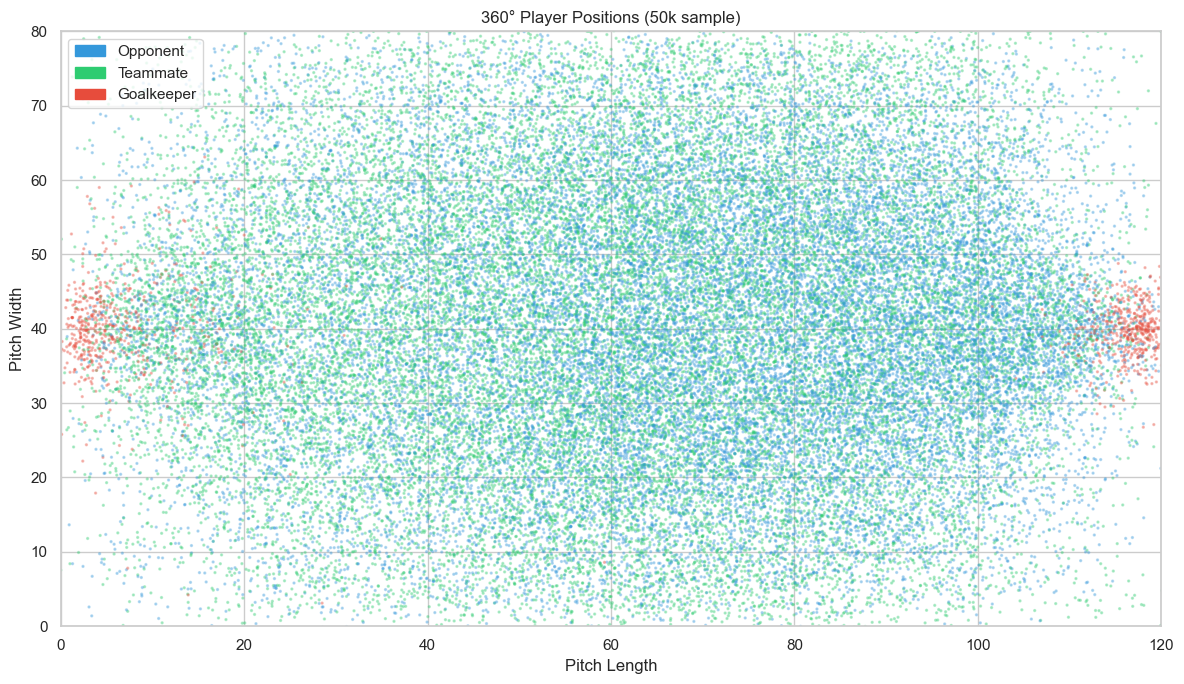

In [24]:
# Sample 50k rows for a quick positional scatter (avoids loading 284 MB)
sample_360 = duck(f"""
    SELECT location_x, location_y, teammate, keeper
    FROM read_parquet('{SB_360}')
    USING SAMPLE 50000 ROWS
""")

fig, ax = plt.subplots(figsize=(12, 7))
colors = sample_360.apply(
    lambda r: '#e74c3c' if r['keeper'] else ('#2ecc71' if r['teammate'] else '#3498db'),
    axis=1
)
ax.scatter(sample_360['location_x'], sample_360['location_y'],
           c=colors, s=2, alpha=0.3)
ax.set_xlim(0, 120)
ax.set_ylim(0, 80)
ax.set_title('360° Player Positions (50k sample)')
ax.set_xlabel('Pitch Length')
ax.set_ylabel('Pitch Width')
patches = [
    mpatches.Patch(color='#3498db', label='Opponent'),
    mpatches.Patch(color='#2ecc71', label='Teammate'),
    mpatches.Patch(color='#e74c3c', label='Goalkeeper'),
]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sb_threesixty_positions_sample.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. StatsBomb — Reference

In [25]:
ref = pd.read_parquet(SB_REF)
print(f'Shape: {ref.shape}')
ref.head()

Shape: (9566, 4)


,table_name,id,name,extra_info
0,team,2021,Jamshedpur,male
1,team,7285,NorthEast United,male
2,team,865,England Women's,female
3,team,852,Norway Women's,female
4,team,1209,Chile Women's,female


In [26]:
print('Entities per table:')
print(ref.groupby('table_name')['id'].count().sort_values(ascending=False).to_string())

Entities per table:
table_name
player          9043
team             312
country          141
event_type        35
position          26
play_pattern       9


---
## 6. Polymarket — Markets

In [27]:
markets = pd.read_parquet(PM_MARKETS)
print(f'Shape: {markets.shape}')
markets.head()

Shape: (8549, 10)


,market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
0,242920,Will Ukraine qualify for the 2022 FIFA World Cup?,will-ukraine-qualify-to-the-2022-fifa-world-cup,will-ukraine-qualify-to-the-2022-fifa-world-cup,Sports,4766.88,True,True,2022-04-06 07:51:48,2022-06-30
1,244963,UEFA Europa League final: Who will win Eintracht vs. Ran...,uefa-europa-league-final-who-will-win-eintracht-vs-rangers,uefa-europa-league-final-who-will-win-eintracht-vs-rangers,Sports,1543.29,True,True,2022-05-18 14:16:53,2022-05-18
2,246443,Soccer: Who will win the United States vs. Uruguay inter...,soccer-who-will-win-the-united-states-vs-uruguay-interna...,soccer-who-will-win-the-united-states-vs-uruguay-interna...,Sports,1363.07,True,True,2022-06-05 12:45:16,2022-06-05
3,246490,UEFA Nations League: Who will win the Germany vs. Englan...,uefa-nations-league-who-will-win-the-germany-vs-england-...,uefa-nations-league-who-will-win-the-germany-vs-england-...,Sports,1031.58,True,True,2022-06-06 17:09:19,2022-06-07
4,246661,2022 Wimbledon Championships: Who will win Kyrgios vs. N...,2022-wimbledon-championships-who-will-win-kyrgios-vs-nadal,2022-wimbledon,Sports,3098.29,True,True,2022-07-06 19:33:08,2022-07-08


In [28]:
print('Data types:')
print(markets.dtypes)
print('\nMissing values:')
print(markets.isnull().sum())

Data types:
market_id                str
question                 str
slug                     str
event_slug               str
category                 str
volume               float64
active                  bool
closed                  bool
created_at    datetime64[us]
end_date      datetime64[us]
dtype: object

Missing values:
market_id      0
question       0
slug           0
event_slug     0
category       0
volume         0
active         0
closed         0
created_at     0
end_date      15
dtype: int64


In [29]:
print(f'Total markets  : {len(markets):,}')
print(f'Active markets : {markets["active"].sum():,}')
print(f'Closed markets : {markets["closed"].sum():,}')
print(f'Total volume   : ${markets["volume"].sum():,.0f}')
print(f'Median volume  : ${markets["volume"].median():,.0f}')

Total markets  : 8,549
Active markets : 8,549
Closed markets : 7,140
Total volume   : $3,033,517,308
Median volume  : $9,538


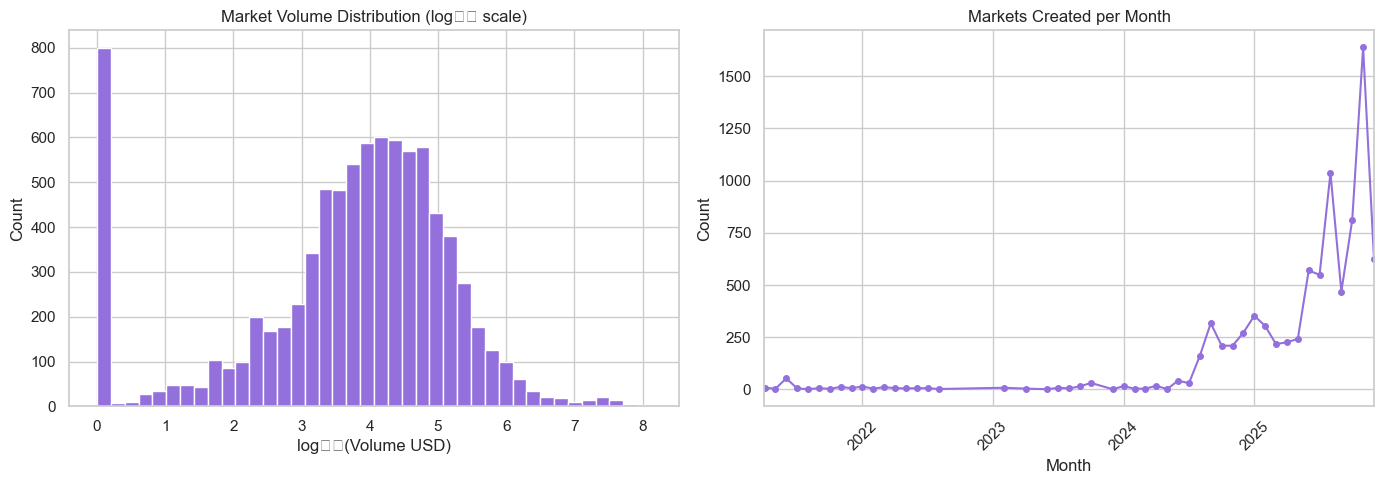

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume distribution (log scale)
vol = markets['volume'].clip(lower=1)
axes[0].hist(np.log10(vol), bins=40, color='mediumpurple', edgecolor='white')
axes[0].set_title('Market Volume Distribution (log₁₀ scale)')
axes[0].set_xlabel('log₁₀(Volume USD)')
axes[0].set_ylabel('Count')

# Markets created over time
markets['created_month'] = pd.to_datetime(markets['created_at']).dt.to_period('M')
monthly = markets.groupby('created_month').size()
monthly.plot(ax=axes[1], color='mediumpurple', marker='o', markersize=4)
axes[1].set_title('Markets Created per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pm_market_volume_and_created_monthly.png'), dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Top markets by volume
top_markets = markets.nlargest(15, 'volume')[['question','volume','closed','created_at','end_date']]
top_markets['volume'] = top_markets['volume'].map('${:,.0f}'.format)
top_markets.reset_index(drop=True)

,question,volume,closed,created_at,end_date
0,Will Aston Villa win the UEFA Champions League?,"$133,113,813",True,2024-09-17 17:21:16,2025-05-31 12:00:00
1,Nottingham Forest wins the Premier League?,"$101,429,202",True,2024-09-09 19:33:14,2025-05-25 12:00:00
2,Southampton wins the Premier League?,"$88,209,349",True,2024-09-09 19:33:35,2025-05-25 12:00:00
3,Will Inter Milan win the UEFA Champions League?,"$82,978,657",True,2024-09-17 17:27:16,2025-05-31 12:00:00
4,Will Real Betis win La Liga?,"$71,762,810",True,2024-09-18 02:39:50,2025-05-25 12:00:00
5,Manchester United wins the Premier League?,"$71,063,868",True,2024-09-09 19:32:26,2025-05-25 12:00:00
6,Will Red Star Belgrade win the UEFA Champions League?,"$69,281,806",True,2024-09-17 17:35:44,2025-05-31 12:00:00
7,Brighton & Hove Albion wins the Premier League?,"$67,314,792",True,2024-09-09 19:27:55,2025-05-25 12:00:00
8,Will Paris Saint-Germain win the UEFA Champions League?,"$51,320,576",True,2024-09-17 17:30:16,2025-05-31 12:00:00
9,Everton wins the Premier League?,"$47,715,615",True,2024-09-09 19:29:10,2025-05-25 12:00:00


---
## 7. Polymarket — Tokens

In [32]:
tokens = pd.read_parquet(PM_TOKENS)
print(f'Shape: {tokens.shape}')
tokens.head(10)

Shape: (17096, 3)


,market_id,token_id,outcome
0,507139,11383642491302591627139896622717888470522517609918423358...,Yes
1,507139,50504089574051966408848895921907548607103929851833431636...,No
2,507140,11288018854040475606377985885243613911136629300700664546...,Yes
3,507140,11395087389782822432249735900885094684054139268057488194...,No
4,507142,11925049625837683963679095371398851146416222881067943257...,Yes
5,507142,59853202086937726252884676018984709453488560147578132815...,No
6,507146,10417065904349156304816223919766983268182573364146803258...,Yes
7,507146,89647832811447716772745375632762854397192109526374841594...,No
8,507147,99589481028582031463280512735907637015967048865247645081...,Yes
9,507147,21954883161924311296952565516037886988548625135027115992...,No


In [33]:
# Tokens per market
tpm = tokens.groupby('market_id')['token_id'].count()
print('Tokens per market:')
print(tpm.value_counts().sort_index())
print(f'\nMost common outcomes: {tokens["outcome"].value_counts().head(10).to_dict()}')

Tokens per market:
token_id
2    8545
3       2
Name: count, dtype: int64

Most common outcomes: {'Yes': 7375, 'No': 7375, 'Over': 572, 'Under': 572, 'Liverpool': 15, 'Chelsea': 14, 'Olympique Lyonnais': 13, 'Tottenham': 13, 'OGC Nice': 12, 'Olympique de Marseille': 12}


---
## 8. Polymarket — Trades (123 MB, DuckDB)

In [34]:
n_trades = duck(f"SELECT COUNT(*) AS n FROM read_parquet('{PM_TRADES}')")['n'][0]
print(f'Total trades: {n_trades:,}')

print('\nSchema:')
display(duck(f"DESCRIBE SELECT * FROM read_parquet('{PM_TRADES}')"))

Total trades: 1,138,914

Schema:


,column_name,column_type,null,key,default,extra
0,trade_id,VARCHAR,YES,None,None,None
1,market_id,VARCHAR,YES,None,None,None
2,token_id,VARCHAR,YES,None,None,None
3,timestamp,TIMESTAMP,YES,None,None,None
4,price,DOUBLE,YES,None,None,None
5,size,DOUBLE,YES,None,None,None
6,side,VARCHAR,YES,None,None,None
7,maker_address,VARCHAR,YES,None,None,None
8,taker_address,VARCHAR,YES,None,None,None


In [35]:
# Trade stats
trade_stats = duck(f"""
    SELECT
        side,
        COUNT(*)                    AS trade_count,
        ROUND(SUM(size), 2)         AS total_size,
        ROUND(AVG(price), 4)        AS avg_price,
        ROUND(MIN(price), 4)        AS min_price,
        ROUND(MAX(price), 4)        AS max_price
    FROM read_parquet('{PM_TRADES}')
    GROUP BY side
""")
trade_stats

,side,trade_count,total_size,avg_price,min_price,max_price
0,SELL,203315,5.581658e+07,0.5337,0.001,0.999
1,BUY,935599,2.783334e+08,0.5114,0.001,0.999


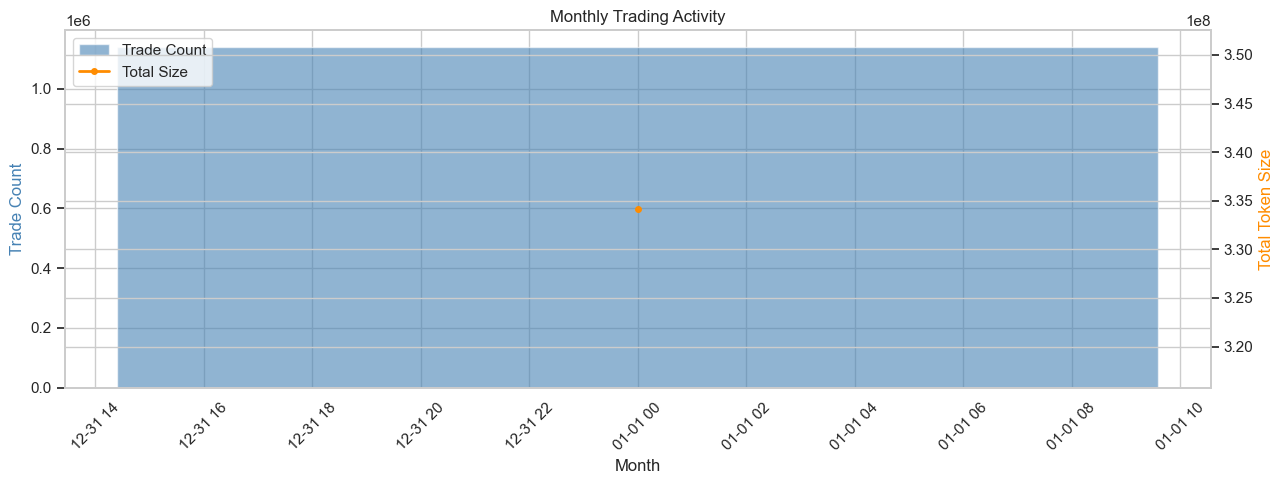

In [36]:
# Trading volume over time (monthly)
monthly_trades = duck(f"""
    SELECT
        DATE_TRUNC('month', timestamp) AS month,
        COUNT(*)                        AS num_trades,
        ROUND(SUM(size), 0)             AS total_size
    FROM read_parquet('{PM_TRADES}')
    GROUP BY 1
    ORDER BY 1
""")

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_trades['month'], monthly_trades['num_trades'],
        color='steelblue', alpha=0.6, label='Trade Count')
ax2.plot(monthly_trades['month'], monthly_trades['total_size'],
         color='darkorange', linewidth=2, marker='o', markersize=4, label='Total Size')

ax1.set_title('Monthly Trading Activity')
ax1.set_xlabel('Month')
ax1.set_ylabel('Trade Count', color='steelblue')
ax2.set_ylabel('Total Token Size', color='darkorange')
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pm_monthly_trading_activity.png'), dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Top traders by volume
top_traders = duck(f"""
    SELECT taker_address,
           COUNT(*) AS trades,
           ROUND(SUM(size), 2) AS total_size
    FROM read_parquet('{PM_TRADES}')
    GROUP BY taker_address
    ORDER BY total_size DESC
    LIMIT 15
""")
top_traders

,taker_address,trades,total_size
0,0xc5d563a36ae78145c45a50134d48a1215220f80a,321104,1.147669e+08
1,,332565,8.550687e+07
2,0x204f72f35326db932158cba6adff0b9a1da95e14,19034,1.061202e+07
3,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,30894,6.638083e+06
4,0x2635b7fb040d817f4c7e7f45fdd116bf476d5408,456,6.446341e+06
5,0x83b9f9e2d28ab875b9c9f73cdd5535c4c8926124,11382,3.192150e+06
6,0x0764a6f5e2f3c62bd3686c50b0b0b95279f1e01f,128,2.438197e+06
7,0xdf2e12c6a53671d0b08f29d0391728097029ddec,517,1.872099e+06
8,0xa49becb692927d455924583b5e3e5788246f4c40,2608,1.699957e+06
9,0xea64572947a01f9938fd5474dc3b7d219352f2a2,293,1.676072e+06


---
## 9. Polymarket — Odds History

In [38]:
odds = pd.read_parquet(PM_ODDS)
print(f'Shape: {odds.shape}')
odds.head()

Shape: (666837, 4)


,market_id,token_id,timestamp,price
0,566735,22667617953671803775562636820557023939003625390106866761...,1970-01-21 07:09:07.210,0.0550
1,566735,22667617953671803775562636820557023939003625390106866761...,1970-01-21 07:10:33.610,0.0320
2,566735,22667617953671803775562636820557023939003625390106866761...,1970-01-21 07:12:00.008,0.0190
3,566735,22667617953671803775562636820557023939003625390106866761...,1970-01-21 07:13:26.409,0.0255
4,566735,22667617953671803775562636820557023939003625390106866761...,1970-01-21 07:14:52.809,0.0175


In [39]:
print('Price stats:')
print(odds['price'].describe())
print(f'\nUnique markets : {odds["market_id"].nunique():,}')
print(f'Unique tokens  : {odds["token_id"].nunique():,}')
print(f'Date range     : {odds["timestamp"].min()} → {odds["timestamp"].max()}')

Price stats:
count    666837.000000
mean          0.499987
std           0.323244
min          -0.002500
25%           0.235000
50%           0.500000
75%           0.765000
max           1.002500
Name: price, dtype: float64

Unique markets : 8,322
Unique tokens  : 16,644
Date range     : 1970-01-20 09:51:50.435000 → 1970-01-21 10:59:34.809000


Most-traded market: Will Fulham win on 2025-11-22?


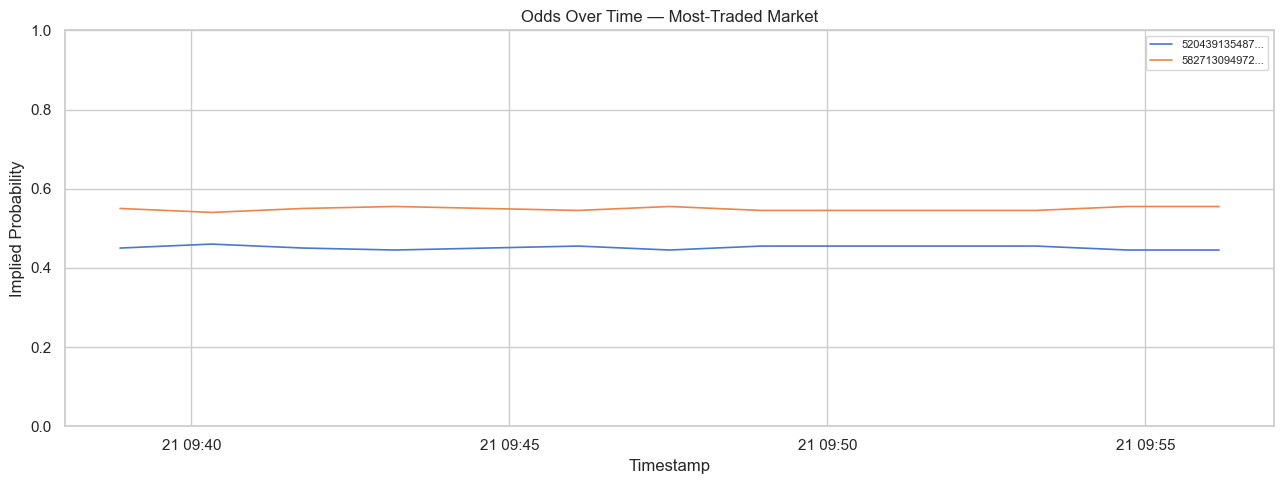

In [40]:
# Pick the most-traded market and plot its odds over time
summary = pd.read_parquet(PM_SUMMARY)
top_market_id = summary.nlargest(1, 'trade_count')['market_id'].iloc[0]
top_market_q  = markets.loc[markets['market_id'] == top_market_id, 'question']
if not top_market_q.empty:
    print(f'Most-traded market: {top_market_q.iloc[0]}')

market_odds = odds[odds['market_id'] == top_market_id].sort_values('timestamp')

if not market_odds.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    for tid, grp in market_odds.groupby('token_id'):
        ax.plot(grp['timestamp'], grp['price'], linewidth=1.2, label=tid[:12] + '...')
    ax.set_title('Odds Over Time — Most-Traded Market')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Implied Probability')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'pm_odds_over_time_top_market.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No odds data found for this market in the snapshot.')

---
## 10. Polymarket — Event Stats & Summary

In [41]:
event_stats = pd.read_parquet(PM_STATS)
print(f'Shape: {event_stats.shape}')
event_stats.head()

Shape: (2640, 5)


,event_slug,market_count,total_volume,first_market_start,last_market_end
0,real-madrid-vs-bayern-munich-ucl-semis-second-leg,1,1.794810e+03,2024-05-06 16:06:33,2024-05-08 12:00:00
1,champions-league-winner-2025,36,1.001677e+09,2024-09-16 22:17:10,2025-05-31 12:00:00
2,epl-ips-mac-2025-01-19,3,1.634703e+05,2025-01-07 01:31:12,2025-01-19 16:30:00
3,epl-che-lei-2025-03-09,3,3.600662e+05,2025-02-24 05:02:19,2025-03-09 14:00:00
4,fifa-world-cup-qualifiers-bolivia-vs-uruguay,3,0.000000e+00,2025-03-24 17:31:10,2025-03-25 12:00:00


In [42]:
print(summary.shape)
summary.head()

(8549, 9)


,market_id,question,slug,volume,active,token_count,trade_count,first_trade,last_trade
0,580986,MLS: Will St. Louis City SC beat Houston?,mls-will-st-louis-city-sc-beat-houston,1312.879974,True,2,31,1970-01-21 07:54:02.835,1970-01-21 07:56:53.760
1,794127,Spread: Paris Saint-Germain FC (-2.5),fl1-met-psg-2025-12-13-spread-away-2pt5,39.473683,True,2,1,1970-01-21 10:18:46.735,1970-01-21 10:18:46.735
2,718033,Will Rangers FC win on 2025-12-11?,uel-ftc-ran1-2025-12-11-ran1,0.000000,True,2,87,1970-01-21 10:18:58.991,1970-01-21 10:21:23.967
3,717467,Will Páfos FC win on 2025-12-10?,ucl-juv-paf-2025-12-10-paf,15436.727519,True,2,24,1970-01-21 10:20:57.909,1970-01-21 10:23:01.640
4,717481,Will Newcastle United FC win on 2025-12-10?,ucl-lev2-new1-2025-12-10-new1,879.557072,True,2,191,1970-01-21 10:09:00.292,1970-01-21 10:23:01.324


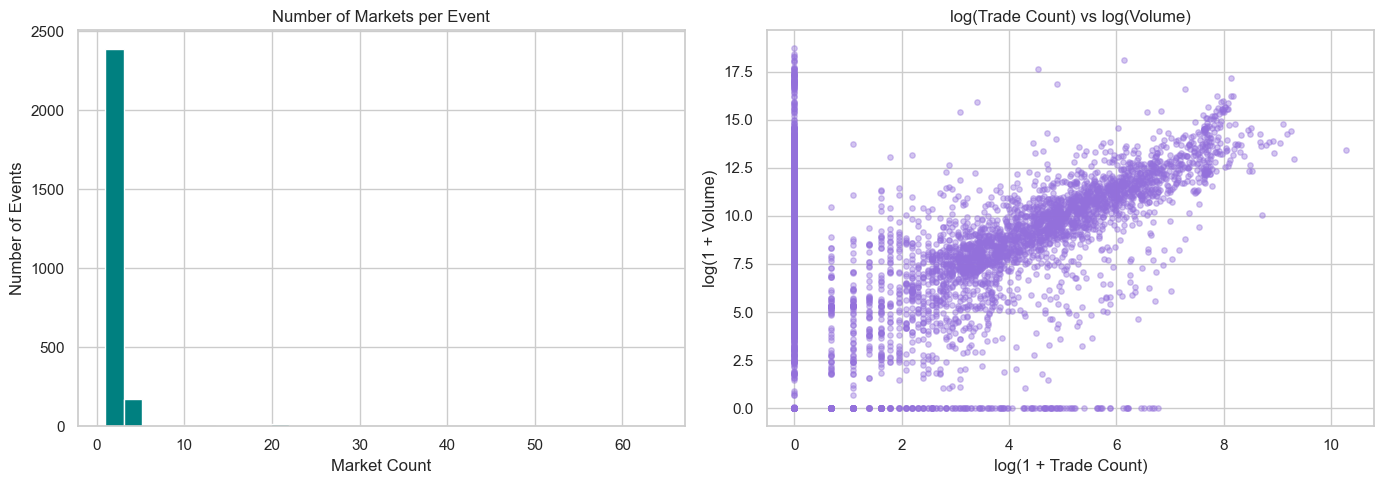

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Markets per event
axes[0].hist(event_stats['market_count'], bins=30, color='teal', edgecolor='white')
axes[0].set_title('Number of Markets per Event')
axes[0].set_xlabel('Market Count')
axes[0].set_ylabel('Number of Events')

# Summary: trade count vs volume scatter
axes[1].scatter(np.log1p(summary['trade_count']),
                np.log1p(summary['volume']),
                alpha=0.4, s=15, color='mediumpurple')
axes[1].set_title('log(Trade Count) vs log(Volume)')
axes[1].set_xlabel('log(1 + Trade Count)')
axes[1].set_ylabel('log(1 + Volume)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pm_markets_per_event_and_trade_volume.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Cross-Dataset — Potential Overlap

The Polymarket `event_slug` field encodes match info (e.g. `epl-ars-che-2025`). We can try to link it to StatsBomb matches by parsing team abbreviations and dates.

In [44]:
# Show sample slugs to understand naming convention
print('Sample event slugs:')
print(event_stats['event_slug'].sample(min(20, len(event_stats)), random_state=42).tolist())

Sample event slugs:
['concacaf-gold-cup-honduras-vs-curacao', 'fl1-met-str-2025-08-17', 'epl-new-bri-2024-10-19', 'uel-fer-plz-2025-09-25', 'epl-tot-ips-2024-11-10', 'bundesliga-vfb-stuttgart-vs-heidenheim', 'epl-bri-ast-2025-12-03-more-markets', 'cde-per-lmf-2025-12-19', 'mls-new-england-revolution-vs-fc-cincinnati', 'epl-mun-sou-2025-01-16', 'uel-ste-fey-2025-12-11-more-markets', 'uel-mid-kps-2025-08-21', 'fifa-club-world-cup-real-madrid-vs-pachuca', 'epl-bri-wes-2025-12-07', 'epl-not-tot-2025-12-14', 'ucl-juv-psv-2025-02-11', 'will-sweden-or-poland-win-their-euro-2020-match-1', 'mls-soccer-austin-fc-vs-fc-dallas', 'mls-soccer-lafc-vs-fc-dallas', 'indian-premier-league-champion-2025']


In [45]:
# How many unique competitions appear in StatsBomb?
sb_comps = matches['competition_name'].unique()
print('StatsBomb competitions:')
print(sb_comps)

# How many distinct event slugs in Polymarket?
print(f'\nPolymarket unique event slugs: {event_stats["event_slug"].nunique():,}')

StatsBomb competitions:
<ArrowStringArray>
[                'La Liga',   'North American League',
                 'Serie A',     'Indian Super league',
  'African Cup of Nations',      'FIFA U20 World Cup',
        'Champions League',          'Premier League',
            'Copa America',      'UEFA Europa League',
 'FA Women's Super League',          'FIFA World Cup',
     'Major League Soccer',                    'NWSL',
       'UEFA Women's Euro',               'UEFA Euro',
                 'Ligue 1',       'Women's World Cup',
        'Liga Profesional',            'Copa del Rey',
           '1. Bundesliga']
Length: 21, dtype: str

Polymarket unique event slugs: 2,640


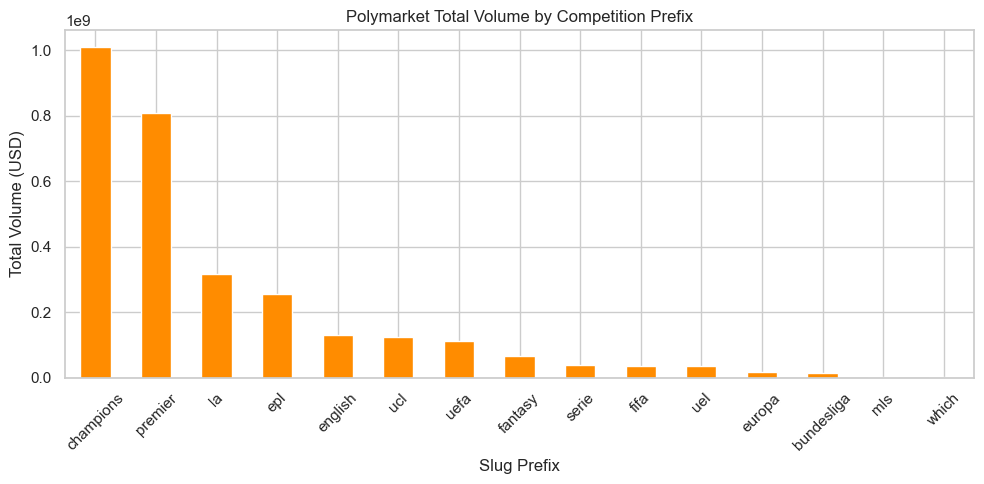

In [46]:
# Volume-by-competition proxy: count slug prefixes
# Many slugs start with a competition code (epl-, ucl-, laliga-, etc.)
event_stats['competition_prefix'] = event_stats['event_slug'].str.extract(r'^([a-z]+)-')
prefix_vol = (event_stats
              .groupby('competition_prefix')['total_volume']
              .sum()
              .sort_values(ascending=False)
              .head(15))

fig, ax = plt.subplots(figsize=(10, 5))
prefix_vol.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Polymarket Total Volume by Competition Prefix')
ax.set_xlabel('Slug Prefix')
ax.set_ylabel('Total Volume (USD)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pm_volume_by_slug_prefix.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Summary

| Dataset | Table | Rows | Key Fields |
|---------|-------|------|------------|
| StatsBomb | matches | — | match_id, competition, season, score |
| StatsBomb | events | ~millions | type, xG, pass_outcome, location |
| StatsBomb | lineups | — | player, position, card |
| StatsBomb | three_sixty | ~millions | tracking coords per frame |
| Polymarket | markets | — | volume, question, created_at |
| Polymarket | trades | ~millions | price, size, side, timestamp |
| Polymarket | odds_history | — | price time-series per token |

**Next steps:**
- Build match-level features from `events` (xG, pass %, pressure events, etc.)
- Join with `lineups` for player-level aggregations
- Parse Polymarket slugs to align with StatsBomb `match_id`
- Train match-outcome classifier (XGBoost) and compare with market-implied probabilities
- PCA + K-Means clustering of player event profiles

---
# EDA Summary

## StatsBomb Open Data

### Matches
- **3,464 matches** across **20 competitions**, stored in 36 columns
- **Largest competitions by match count:** La Liga (868), Ligue 1 (435), Premier League (418), Serie A (381), Bundesliga (340), FA Women's Super League (326)
- **International tournaments:** FIFA World Cup (147), Women's World Cup (116), UEFA Euro (102), African Cup of Nations (52), Copa America (32)
- **Match outcomes across all games:** roughly 45% Home wins, 29% Away wins, 26% Draws — a typical home-advantage distribution
- Season depth is uneven: La Liga has multiple full seasons (e.g. 2015/16: 306 matches), while Champions League contributions are scattered across historical one-off entries

### Events
- **~12.7 million events** in total across all matches (109 columns in the schema, confirming rich nested data has been denormalized)
- **Dominant event types:** Pass (3.39M), Ball Receipt (3.17M), Carry (2.63M), Pressure (1.11M) — together making up ~80% of all events
- **88,023 shots** have xG values; mean xG per shot = **0.107** (median 0.055), reflecting the rarity of high-quality chances
- **Shot locations** are tightly clustered in the attacking third, with a visible penalty-area hotspot
- **Top xG team:** Barcelona (8,401 shots, 1,069 cumulative xG) — partly a function of having the most matches in the dataset
- **Highest pass completion:** Paris Saint-Germain (89.1%), Spain national team (89.0%), Barcelona (86.5%)
- **Event tempo:** activity peaks around minutes 40–45 and 85–90, consistent with end-of-half pressing surges seen in football research

### Lineups
- **165,820 rows** covering **10,808 unique players**, **25 positions**, and **308 teams**
- Notable nulls: `position_name` missing for ~34k rows (players listed without a formal position), `to_time` missing for ~111k rows (likely still on pitch at full-time)
- **19,606 disciplinary actions:** 18,217 Yellow Cards, 697 Second Yellows, 692 Red Cards

### 360° Tracking
- **15.6 million tracking frames** — the largest table by row count
- Each frame records the x/y position of every visible player for a given event, with flags for `actor`, `teammate`, and `keeper`
- Positional scatter confirms players cluster in their respective halves during open play, with goalkeepers tightly distributed near the goal lines

---

## Polymarket Soccer Data

### Markets
- **8,549 markets**, all flagged `active=True` in the snapshot; **7,140 are closed/resolved**
- **Total cumulative volume: ~$3.03 billion USD** — substantial liquidity indicating a mature prediction market
- Volume is **highly skewed:** median market volume is only ~$9,538, but the top market (*Will Aston Villa win the UEFA Champions League?*) reached **$133 million**
- Other high-volume markets include Premier League winner outrights (Nottingham Forest ~$101M, Southampton ~$88M) and Champions League futures — all long-horizon tournament bets
- Market creation shows a growth trend over time; 15 markets have no `end_date`

### Tokens & Outcomes
- **17,096 tokens** across 8,549 markets — almost entirely **binary (Yes/No)** structures (8,545 markets have exactly 2 tokens)
- Only 2 markets have 3 outcome tokens (e.g. multi-team winner markets)
- Beyond Yes/No, the most common named outcomes are Over/Under (572 each) and club-name outcomes for outrights (Liverpool, Chelsea, etc.)

### Trades
- **1,138,914 trades** — heavily skewed toward the BUY side (935,599 BUY vs 203,315 SELL, roughly a 4.6:1 ratio)
- Average execution price: ~0.511 (BUY) and ~0.534 (SELL) — near 50 cents, consistent with uncertain binary markets
- **One wallet dominates:** `0xc5d563...` executed 321,104 trades totalling ~$115M — likely a market maker or automated bot
- A second large block (332,565 trades with a blank address) may represent aggregated or anonymised activity

### Odds History
- **666,837 price snapshots** across 8,322 markets and 16,644 tokens
- Mean price is almost exactly **0.500** (std 0.323), confirming symmetric binary market design
- **Data quality flag:** timestamps cluster around January 1970 (Unix epoch), indicating a millisecond-to-second conversion bug in the export pipeline — must be corrected before any time-series analysis
- A small number of prices fall slightly outside [0, 1] (min −0.0025, max 1.0025), likely rounding artefacts

### Event Stats & Summary
- **2,640 unique events** (match-level or competition-level slugs) with aggregated market counts and volumes
- Competitions represented include EPL (`epl-`), UCL (`ucl-`), UEL (`uel-`), Bundesliga (`bundesliga-`), Ligue 1 (`fl1-`), MLS (`mls-`), and many more
- Most events have **3 markets** (win/draw/loss); major events like *Champions League Winner 2025* carry 36 markets with over $1B combined volume

---

## Cross-Dataset Alignment

| Dimension | StatsBomb | Polymarket |
|-----------|-----------|------------|
| Granularity | Event-level (per touch) | Trade-level (per bet) |
| Match coverage | 3,464 matches, select competitions | ~2,640 match events, broad global coverage |
| Time depth | Historical open data (mixed seasons) | Primarily 2024–2025 season |
| Competition overlap | Premier League, Champions League, Europa League, Ligue 1, La Liga | EPL, UCL, UEL, Bundesliga, Ligue 1, MLS |

- Polymarket `event_slug` follows a parseable pattern (`{competition}-{home3}-{away3}-{date}`) that can be aligned with StatsBomb `match_date` and team names to build a joined dataset
- **Primary join candidates:** EPL, Champions League, and Europa League matches from the 2024/25 season appear in both sources

---

## Data Quality Notes

1. **`odds_history` timestamps are broken** — all dates fall in January 1970 (Unix epoch), caused by a millisecond-to-second conversion bug in the export. Must be fixed before time-series modeling.
2. **`lineups.position_name`** has ~34k nulls — common for substitutes in competitions that do not record a formal positional role.
3. **`lineups.to_time`** is null for ~111k rows — expected for players still on the pitch at full-time.
4. **Polymarket price outliers** — a small number of odds snapshots fall slightly outside [0, 1]; cap or filter before probability modeling.
5. **StatsBomb season coverage is uneven** — Champions League has mostly 1-match historical entries; MLS has only 6 matches.

---

## Recommended Next Steps

1. **Fix `odds_history` timestamps** — reverse the epoch conversion to recover correct datetimes.
2. **Feature engineering from events** — aggregate per match: total xG (home/away), pass completion %, shots on target, pressures, etc. to build a match-level feature matrix.
3. **Match linking** — parse Polymarket slugs and join to StatsBomb `match_id` via date and team abbreviation lookup.
4. **Outcome model** — train an XGBoost classifier on StatsBomb match features and compare predicted probabilities against Polymarket pre-match implied odds.
5. **Player clustering** — use per-player event-type distributions from `events` as features for PCA + K-Means to identify playing style archetypes.
6. **Market inefficiency scan** — identify matches where the model's probability diverges most from Polymarket odds at market open.
